# deprecated

# MSA Preparation - COX2

Convert a3m alignment files to one-hot tensors for coevolution analysis.

**Source**: [AlphaFold DB - P00403](https://alphafold.ebi.ac.uk/entry/AF-P00403-F1) (Cytochrome c oxidase subunit 2)

In [1]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from pathlib import Path

In [2]:
# Alphabet: 20 amino acids + gap
ALPHABET = "ARNDCQEGHILKMFPSTWYV-"
A2I = {aa: i for i, aa in enumerate(ALPHABET)}
I2A = {i: aa for i, aa in enumerate(ALPHABET)}
A = len(ALPHABET)  # 21

## Functions

In [3]:
def parse_a3m(path):
    """Parse a3m file to headers and sequences.
    
    a3m format: lowercase = insertions (ignored), uppercase = aligned positions.
    """
    headers, sequences = [], []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                headers.append(line[1:])
                sequences.append([])
            elif line and sequences:
                # Keep only uppercase (aligned) and gaps
                aligned = "".join(c for c in line if c.isupper() or c == "-")
                sequences[-1].append(aligned)
    sequences = ["".join(s) for s in sequences]
    return headers, sequences

In [4]:
def make_msa(sequences, gap_thresh=0.5, eff_thresh=0.8):
    """Convert sequences to MSA tensors.
    
    Args:
        sequences: list of aligned sequences (same length)
        gap_thresh: remove columns with gap frequency above this
        eff_thresh: cluster sequences at this identity for weighting
    
    Returns:
        dict with:
            X: one-hot MSA (N, L, A) - filtered columns, 20 AAs (no gap)
            X_raw: one-hot MSA (N, L_raw, A+1) - all columns, 21 chars
            non_gap: indices of non-gapped columns
            weights: effective sequence weights (N,)
    """
    # Sequences to integer indices
    raw_idx = np.array([
        [A2I.get(aa.upper(), A2I["-"]) for aa in seq] 
        for seq in sequences
    ])
    N, L_raw = raw_idx.shape
    
    # Find non-gapped columns
    gap_freq = (raw_idx == A2I["-"]).mean(axis=0)
    non_gap = np.where(gap_freq < gap_thresh)[0]
    L = len(non_gap)
    
    # Compute sequence weights (effective sequences)
    identity = 1.0 - squareform(pdist(raw_idx, "hamming"))
    weights = 1.0 / (identity >= eff_thresh).sum(axis=1)
    
    # One-hot encode
    X_raw = np.eye(A)[raw_idx]  # (N, L_raw, 21) with gap
    X = np.eye(A)[raw_idx[:, non_gap]][:, :, :(A - 1)]  # (N, L, 20) no gap
    
    return {
        "X": X.astype(np.float32),
        "X_raw": X_raw.astype(np.float32),
        "non_gap": non_gap,
        "weights": weights.astype(np.float32),
    }

## Data Collation

In [5]:
MSA_PATH = "AF-P00403-F1-msa_v6.a3m"
headers, sequences = parse_a3m(MSA_PATH)
print(f"Parsed {len(sequences)} sequences")
print(f"Raw length: {len(sequences[0])}")

Parsed 17806 sequences
Raw length: 227


In [6]:
msa = make_msa(sequences)

In [7]:
N, L, A = msa["X"].shape
N_eff = msa["weights"].sum()

print(f"X shape: {msa['X'].shape}")
print(f"X_raw shape: {msa['X_raw'].shape}")
print(f"Effective sequences: {N_eff:.1f}")
print(f"Non-gap columns: {len(msa['non_gap'])} / {msa['X_raw'].shape[1]}")

X shape: (17806, 209, 20)
X_raw shape: (17806, 227, 21)
Effective sequences: 5830.0
Non-gap columns: 209 / 227


In [8]:
for x, y in msa.items():
    print(f"{x}: {y.shape if isinstance(y, np.ndarray) else y}")

X: (17806, 209, 20)
X_raw: (17806, 227, 21)
non_gap: (209,)
weights: (17806,)


## Save

In [9]:
out_path = Path(MSA_PATH).stem + ".npz"
np.savez(out_path, **msa)
print(f"Saved to {out_path}")

Saved to AF-P00403-F1-msa_v6.npz


---

# wpgma analysis

In [10]:
# Load downweight vector (contact-based position weights)
DOWNWEIGHT_PATH = "AF-P00403-F1-model_v6_downweight.npz"

dw_data = np.load(DOWNWEIGHT_PATH)
downweight = dw_data["downweight"]  # (L,)

# Handle inf values (positions with 0 long-range contacts)
finite_mask = np.isfinite(downweight)
max_finite = downweight[finite_mask].max()
downweight_capped = np.where(finite_mask, downweight, max_finite)

print(f"Downweight shape: {downweight.shape}")
print(f"Inf positions: {(~finite_mask).sum()} (capped at {max_finite:.4f})")
print(f"Range: [{downweight_capped.min():.4f}, {downweight_capped.max():.4f}]")

# Normalize to sum to 1 for weighted distance
downweight_norm = downweight_capped / downweight_capped.sum()

Downweight shape: (209,)
Inf positions: 0 (capped at 2.0000)
Range: [0.0000, 2.0000]


In [11]:
# Convert one-hot to integer encoding for Hamming distance
X_int = msa["X"].argmax(axis=-1)  # (N, L) integers 0-19
# Convert one-hot to integer encoding for Hamming distance
X_int_full = msa["X"].argmax(axis=-1)  # (N, L) integers 0-19
# Subset to random subselection for compute efficiency
N_SUBSAMPLE = 6000
rng = np.random.default_rng(42)
subsample_idx = rng.choice(X_int_full.shape[0], size=N_SUBSAMPLE, replace=False)
X_int = X_int_full[subsample_idx]
print(f"Subsampled {N_SUBSAMPLE} / {X_int_full.shape[0]} sequences")

Subsampled 6000 / 17806 sequences


In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def weighted_hamming_pdist(X, weights):
    """Memory-efficient weighted Hamming distance."""
    N, L = X.shape
    n_pairs = N * (N - 1) // 2
    distances = np.zeros(n_pairs)
    
    idx = 0
    for i in range(N):
        diff = X[i] != X[i+1:]  # (N-i-1, L)
        d = (diff * weights).sum(axis=1)
        distances[idx:idx+len(d)] = d
        idx += len(d)
        if (i + 1) % 500 == 0:
            print(f"  Progress: {i+1}/{N}")
    return distances

# Compute distance matrices
print("Computing UPGMA distances (unweighted Hamming)...")
D_upgma_condensed = pdist(X_int, metric="hamming")
D_upgma = squareform(D_upgma_condensed)

print("Computing WPGMA distances (weighted Hamming)...")
D_wpgma_condensed = weighted_hamming_pdist(X_int, downweight_norm)
D_wpgma = squareform(D_wpgma_condensed)

print(f"UPGMA range: [{D_upgma_condensed.min():.4f}, {D_upgma_condensed.max():.4f}]")
print(f"WPGMA range: [{D_wpgma_condensed.min():.4f}, {D_wpgma_condensed.max():.4f}]")

Computing UPGMA distances (unweighted Hamming)...
Computing WPGMA distances (weighted Hamming)...
  Progress: 500/6000
  Progress: 1000/6000
  Progress: 1500/6000
  Progress: 2000/6000
  Progress: 2500/6000
  Progress: 3000/6000
  Progress: 3500/6000
  Progress: 4000/6000
  Progress: 4500/6000
  Progress: 5000/6000
  Progress: 5500/6000
  Progress: 6000/6000
UPGMA range: [0.0000, 0.9904]
WPGMA range: [0.0000, 1.0000]


In [13]:
# Build trees
print("Building UPGMA tree...")
Z_upgma = linkage(D_upgma_condensed, method="average")

print("Building WPGMA tree...")
Z_wpgma = linkage(D_wpgma_condensed, method="average")

# Cophenetic correlations
coph_upgma, coph_dist_upgma = cophenet(Z_upgma, D_upgma_condensed)
coph_wpgma, coph_dist_wpgma = cophenet(Z_wpgma, D_wpgma_condensed)

print(f"\nCophenetic correlation (UPGMA): {coph_upgma:.4f}")
print(f"Cophenetic correlation (WPGMA): {coph_wpgma:.4f}")

# Distance matrix correlation
dist_corr, _ = spearmanr(D_upgma_condensed, D_wpgma_condensed)
print(f"Distance matrix correlation: {dist_corr:.4f}")

Building UPGMA tree...
Building WPGMA tree...

Cophenetic correlation (UPGMA): 0.8427
Cophenetic correlation (WPGMA): 0.8028
Distance matrix correlation: 0.9521


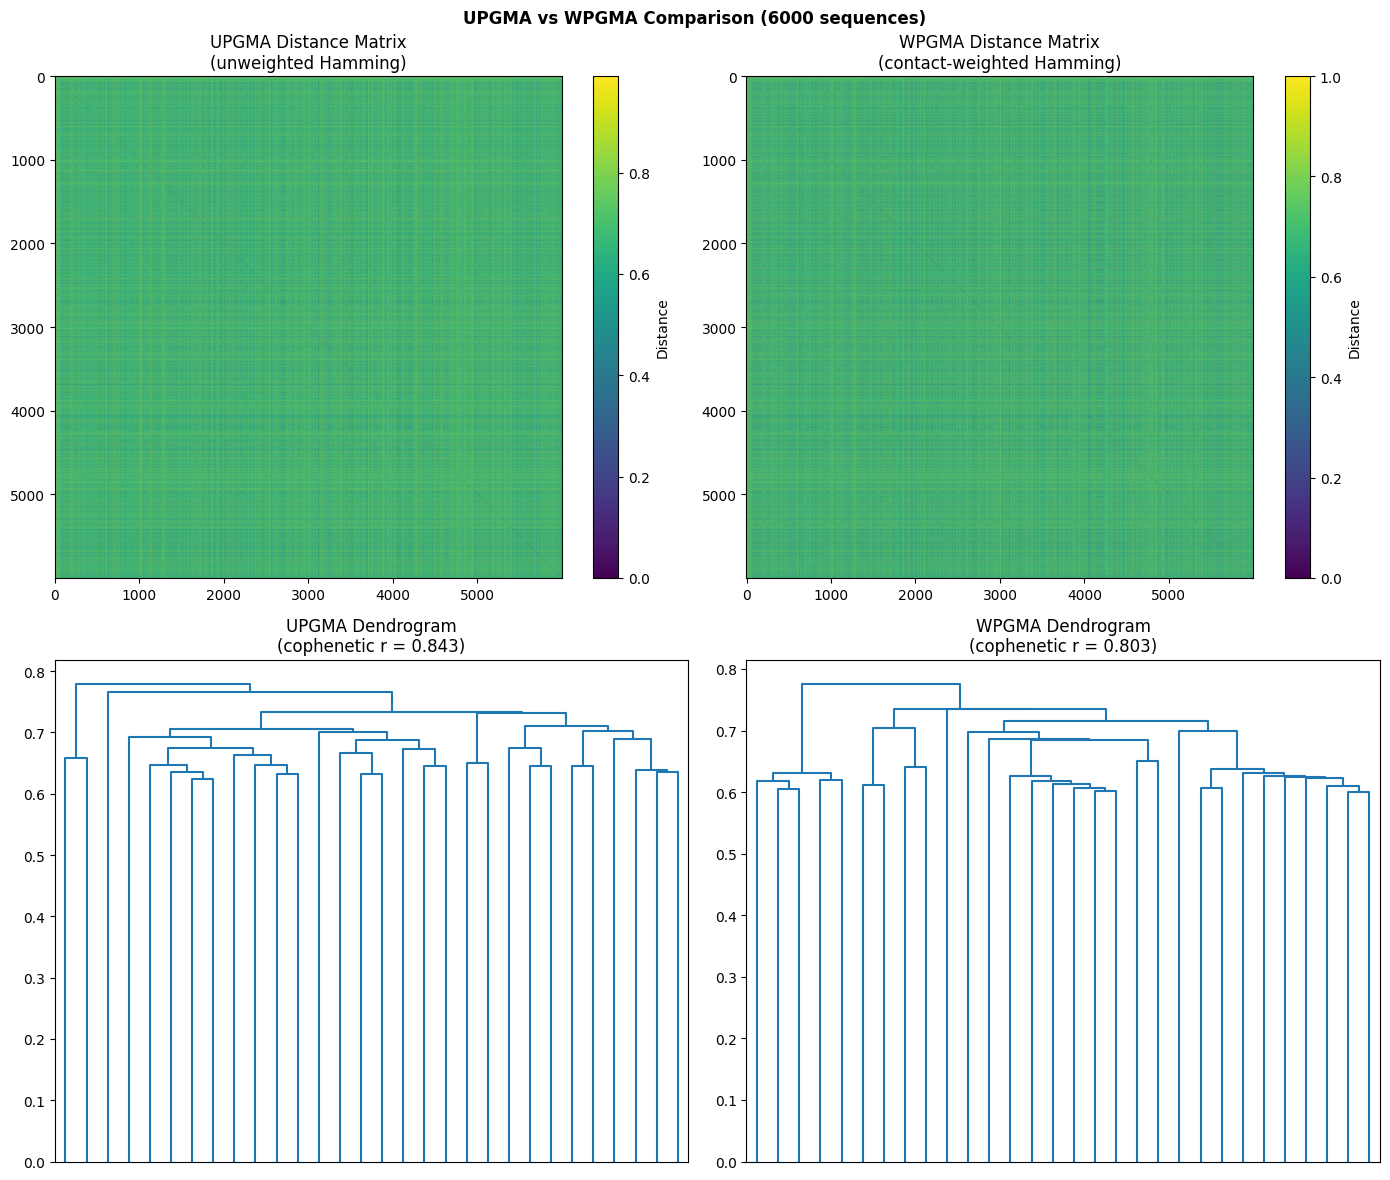

In [14]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Distance matrices
im0 = axes[0, 0].imshow(D_upgma, cmap="viridis", aspect="auto")
axes[0, 0].set_title("UPGMA Distance Matrix\n(unweighted Hamming)")
plt.colorbar(im0, ax=axes[0, 0], label="Distance")

im1 = axes[0, 1].imshow(D_wpgma, cmap="viridis", aspect="auto")
axes[0, 1].set_title("WPGMA Distance Matrix\n(contact-weighted Hamming)")
plt.colorbar(im1, ax=axes[0, 1], label="Distance")

# Dendrograms
dendrogram(Z_upgma, ax=axes[1, 0], truncate_mode="lastp", p=30,
           leaf_rotation=90, no_labels=True)
axes[1, 0].set_title(f"UPGMA Dendrogram\n(cophenetic r = {coph_upgma:.3f})")

dendrogram(Z_wpgma, ax=axes[1, 1], truncate_mode="lastp", p=30,
           leaf_rotation=90, no_labels=True)
axes[1, 1].set_title(f"WPGMA Dendrogram\n(cophenetic r = {coph_wpgma:.3f})")

plt.suptitle(f"UPGMA vs WPGMA Comparison ({N_SUBSAMPLE} sequences)", fontweight="bold")
plt.tight_layout()
plt.savefig("phylo_comparison.png", dpi=150)
plt.show()

# Complex I